<a href="https://colab.research.google.com/github/a00377571/IBM-Python101/blob/main/EquipoXX_semana05Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Maestría en Inteligencia Artificial Aplicada**

## Curso: **Procesamiento de Lenguaje Natural**

### Tecnológico de Monterrey

### Prof Luis Eduardo Falcón Morales

### **Actividad en Equipo - Semanas 4 y 5**

### **Vectores Embebidos de HuggingFace**

2da version Hasta la pregunta 10

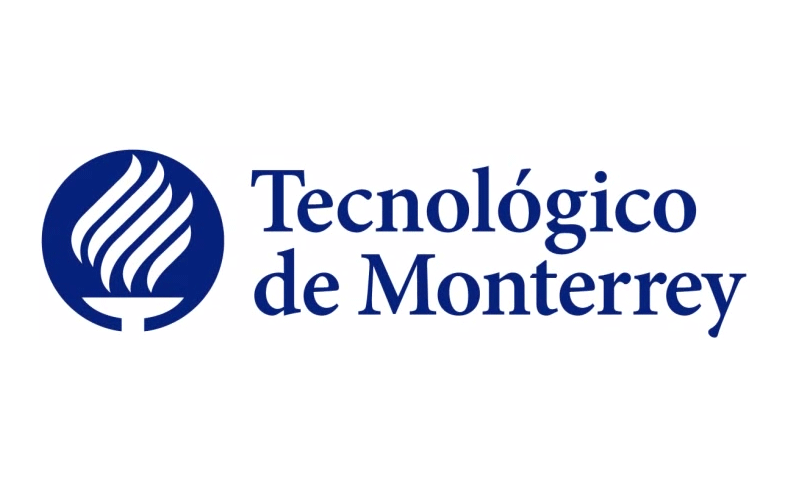

#### **Nombres y matrículas de los integrantes del equipo:**



*   A00377571-Marco Antonio Arellano Hernández
*   A01797374- David Felipe Hernández Chiapa
*   A01797330- Jorge Sánchez Rodríguez



In [71]:
# Aquí deberán incluir todas las librerías que requieran durante esta actividad:

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from sentence_transformers import SentenceTransformer
None



En esta actividad deberás utilizar los datos de tres archivos que se encuentran en el repositorio de la UCI llamados **amazon_cells_labelled.txt**, **imdb_labelled.txt** y   **yelp_labelled.txt**. Cada uno de estos archivos corresponden a comentarios de usuarios que adquirieron un celular a través de la plataforma de Amazon, de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMDb y sobre servicios de comida dejados en la plataforma de Yelp.

La información del problema y de los archivos están basados en el repositorio de la UCI cuya liga es la siguiente:

https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



# **Pregunta - 1:**



Descarga los 3 archivos de la plataforma de la UCI indicado previamente y genera un nuevo DataFrame de Pandas con ellos.

**Llama simplemente "df" a dicho DataFrame.**




In [6]:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

dfa = pd.read_csv('amazon_cells_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
dfi = pd.read_csv('imdb_labelled.txt', delimiter='\t', names=['review','label'], header=None, encoding='utf-8')
dfy = pd.read_csv('yelp_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')

print('Total de registros de Amazon:',dfa.shape)
print('Total de registros de IMBD:',dfi.shape)
print('Total de registros de Yelp:',dfy.shape)

# *********** Aquí termina la sección de agregar código *************
# En particular, el archivo de datos de la IMDb requiere corregirse para obtener los 1000 registros que lo forman.
newdfi=[]     # lista de salida que deberá tener los 1000 registros ya debidamente separados.

# Función para limpiar el texto de la reseña: utiliza expresiones regulares para eliminar caracteres no deseados.
def clean_review_text(text):
    # Eliminar comillas dobles, comillas simples y paréntesis
    # Y luego strip para eliminar espacios en blanco al inicio y al final.
    cleaned_text = re.sub(r'["\'()]', '', text).strip()
    return cleaned_text

for index, row in dfi.iterrows():
    full_review_content = str(row['review'])
    original_label = row['label'] # Esta es la etiqueta de la fila original del DataFrame dfi

    # Usar re.finditer para obtener objetos de coincidencia con sus posiciones
    matches = list(re.finditer(r'([^\n]+?)\t(\d+)', full_review_content))

    if matches:
        last_match_end = 0
        for match in matches:
            review_text, label_str = match.groups()
            cleaned_review = clean_review_text(review_text)
            try:
                label = int(label_str)
                if cleaned_review: # Solo añadir si no está vacío después de la limpieza
                    newdfi.append([cleaned_review, label])
            except ValueError:
                pass
            last_match_end = match.end()

        # Comprobar si queda algún contenido después de la última coincidencia del regex
        remaining_content = full_review_content[last_match_end:].strip()
        if remaining_content:
            # Si hay contenido restante, tratarlo como una reseña y asociarlo con la etiqueta original
            cleaned_remaining_review = clean_review_text(remaining_content)
            if cleaned_remaining_review: # Solo añadir si no está vacío después de la limpieza
                newdfi.append([cleaned_remaining_review, original_label])

    else:
        # Si no se encontraron patrones explícitos 'reseña\tetiqueta', tratar todo el contenido como una sola reseña
        # y asociarlo con la etiqueta original de la fila del DataFrame dfi.
        cleaned_review = clean_review_text(full_review_content)
        if cleaned_review: # Solo añadir si no está vacío después de la limpieza
            newdfi.append([cleaned_review, original_label])


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO CORRECCIÓN DE 1000 REGISTROS.
################################################################################

print('Total de comentarios de la lista errónea original de IMBD:', (len(dfi)))
print('Total de comentarios de la nueva lista corregida de IMBD:', (len(newdfi)))

#Transformemos en un DataFrame la lista recién generada de los comentarios (review)
#y evaluaciones (label) del conjunto de evaluaciones de películas IMBD:

dfii = pd.DataFrame(newdfi, columns=['review','label'])

dfii.info()
dfii.head()

#despliega el tamaño del DataFrame “df” y verifica que efectivamente tienes los 3000 registros con sus respectivas etiquetas.

df = pd.concat([dfa, dfii, dfy], ignore_index=True)



# *********** Aquí termina la sección de agregar código *************


Total de registros de Amazon: (1000, 2)
Total de registros de IMBD: (748, 2)
Total de registros de Yelp: (1000, 2)
Total de comentarios de la lista errónea original de IMBD: 748
Total de comentarios de la nueva lista corregida de IMBD: 1000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [7]:
# Verifiquemos la información del DataFrame:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  3000 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [8]:
# Y mostremos sus primeros registros:

df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [9]:
# Verifiando los "comentarios" de los registros 1125 y 1788:

df.loc[1125, 'review'] = df.loc[1125, 'review'].replace('10/10', 'ten out of ten')
df.loc[1788, 'review'] = df.loc[1788, 'review'].replace('10/10', 'ten out of ten')

print(df.iloc[1125,:])
print(df.iloc[1788,:])

review    ten out of ten
label                  1
Name: 1125, dtype: object
review    ten out of ten
label                  1
Name: 1788, dtype: object


In [10]:
 # Ahora separemos la información:
 #     La "X" serán los datos de entrada, los comentarios.
 #     La "Y" será la variable de salida, las etiquetas de la evaluación.
 # Ambos, X y Y son "Series"

X = df.review     # Serie de strings
y = df.label      # Serie de enteros 0s y 1s

assert X.shape == (3000,)           # Verificando que tenemos la dimensiones esperadas.
assert y.shape == (3000,)           # Si todo va bien, no debe mostrarse algún tipo de error al ejectuar esta celda.

In [11]:
nltk.download('punkt')    # es un tokenizador que ayuda a dividr el texto en enunciados mediante un modelo no-supervisado.
nltk.download('stopwords')    # para tener acceso a "stopwords" en varios idiomas.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Stopwords:

Como en un problema de análisis de sentimiento solo se desea determinar si un comentario es una reseña positivas o una reseña negativa, pudiera ser importante considerar los conectivos "negativos". Como dichos conectivos están incluidos de manera predeterminada en la lista de "stopwords" de la librería NLTK, los vamos a excluir de dicha lista, para que sí sean parte del vocabulario que estaremos analizando.

A la nueva lista de stopwords la llamaremos mystopwords.



In [12]:
# Veamos la lista de stopwords que se incluyen de manera predeterminada la suite de librerías de NLTK:

print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [13]:
# Consideremos la siguiente lista de palabras asociada a negaciones en inglés:

negwords = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

# Y las excluimos de las stopwords:
mystopwords = [ w for w in stopwords.words('english') if w not in negwords]


print("Total de stopwords en la lista original de NLTK: %d" % len(stopwords.words('english')))
print("Total de sotpwords excluyendo los conectivos negativos: %d\n" % len(mystopwords))

# Nuestra nueva lista:
print(mystopwords)

Total de stopwords en la lista original de NLTK: 198
Total de sotpwords excluyendo los conectivos negativos: 158

['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'd', 'did', 'do', 'does', 'doing', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'has', 'have', 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'more', 'most', 'my', 'myself', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'she', "she'd", "she'll", "she's", 'should', "should've", 'so', 'some', 'such', 't', 'than', 'that', "that'll", 'the', 'their', 'theirs', 'them', 'themselves', 'th

# **Pregunta - 2:**

Proceso de limpieza. Aplica el proceso de limpieza que consideres adecuado.


Realiza un proceso de limpieza. Aplica el preprocesamiento que consideres adecuado a todos los
comentarios. No elimines comentarios. Llama “Xclean” a los comentarios procesados y “y” a sus etiquetas.










En esta etapa deberás llevar a cabo el proceso de limpieza y tokenización de los comentarios de texto.

Deberás de incluir los procesos que se indicarán a continuación, aunque no necesariamente deben ser en en el orden estricto que se indica. De hecho, deberás estar revisando la salida de algunos de los registros para que determines cuál consideras podría ser el mejor orden de estos pasos.

La incluiremos en una función llamada "clean_tok()" ya que es la tokenización y limpieza básica de cada uno de los 3000 comentarios. La entrada de esta función son cada uno de estos 3000 strings/comentarios.

Lo que nos regresa "clean_tok()" es una lista de tokens/strings ya simplificados de cada comentario de entrada.

Los pasos a incluir son los siguientes (repito, tú deberás determinar el orden de ellos, aquí se incluyen en orden alfabético):

Caracteres alfabéticos: Solo considerar caracteres alfabéticos. Por lo tanto, deberán ser eliminados signos de puntuación, caracteres especiales y números.

Longitud mayor a 1: Se deben considerar solamente tokens de longitud mayor a 1.

Minúsculas: Simplificar todo a minúsculas.

Stopwords: Eliminar las stopwords.

Tokenización: Cada comentario queda tokenizado por palabras, o cadena de caracteres alfabéticos.

Por ejemplo, si el primer comentario de X fuera el string 'All you need is love!', lo que nos regresaría clean_tok() sería una lista con dos tokens: ['need', 'love'].

In [14]:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

def clean_tok(doc):
  ##############################################################################
  # AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 4:

  # 1. Convertir a minúsculas
  doc = doc.lower()

  # 2. Considerar solo caracteres alfabéticos (eliminar puntuación, caracteres especiales y números)
  # Reemplaza cualquier cosa que no sea una letra con un espacio
  doc = re.sub(r'[^a-z]', ' ', doc)

  # 3. Tokenización: Dividir el comentario en palabras
  tokens = doc.split()

  # 4. Eliminar las stopwords
  # Asegúrate de que 'mystopwords' esté definido y disponible en el entorno global
  tokens = [word for word in tokens if word not in mystopwords]

  # 5. Considerar solamente tokens de longitud mayor a 1
  tokens = [word for word in tokens if len(word) > 1]


  # FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
  ##############################################################################

  return tokens


Xcleantok = [clean_tok(x) for x in X]


# *********** Aquí termina la sección de agregar código *************

In [15]:
# Despleguemos los primeros comentarios después de tu proceso de limpieza:

for x in Xcleantok[0:5]:
  print(x)


['no', 'way', 'plug', 'us', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tied', 'charger', 'conversations', 'lasting', 'minutes', 'major', 'problems']
['mic', 'great']


Veamos los primeros comentarios.

En particular observa si "minutes" y "major" están como dos tokens separados en el cuarto comentario. De nos ser así, si aparecen juntos como un solo token, debes revisar tu proceso de limpieza anterior, porque esto significa que pueden existir otros muchos casos que nos llevan a esta salida no deseada. Trata de determinar el origen de este problema y corregirlo (y solo en caso de que te haya aparecido como un solo token "minutesmajor", en el cuarto comentario).

Procesos adicionales de limpieza.
Por ejemplo, puedes decidir aplicar algunos procesos (regex) para simplificar conjugaciones de verbos regulares y no incluir terminaciones en "s", "ed" o "ing". Puedes también decidir aplicar alguna de las técnicas de stemming o de lemmatization, etc.

NOTA: Deberás aplicar al menos dos procesos de limpieza o normalización adicionales en esta función que llamamos simplemente clean_doc().

La entrada son cada una de las listas con los comentarios tokenizados de Xcleantok y la salida es una lista de tokens simplficados/normalizados con el nombre de "tokens". En dado caso, algunos de los comentarios tokenizados pudieran no surgir cambio alguno bajo esta función.

Recuerda que el objetivo de esta función "clean_doc()" es tener datos más limpios para el proceso de entrenamiento con los algoritmos de aprendizaje automático que se realizarán en las últimas preguntas.

Puedes inspeccionar de manera aleatoria algunos de los 3000 registros para determinar qué procesos de limpieza adicionales incluir.

In [16]:
def clean_doc(doc):

  # Inicializar el stemmer de Porter
  stemmer = PorterStemmer()
  tokens = []

  for token in doc:
    # Proceso de limpieza adicional 1: Normalizar caracteres repetidos con regex
    # Reemplaza 3 o más caracteres idénticos consecutivos por dos (ej. "gooood" -> "good")
    token = re.sub(r'(.)\1\1+', r'\1\1', token)

    # Proceso de limpieza adicional: Simplificar conjugaciones con regex (s, ed, ing)
    # Nota: PorterStemmer (aplicado a continuación) ya maneja estos casos de manera más robusta.
    # Estos regex se aplican antes del stemmer para demostrar su uso específico.
    token = re.sub(r'ing$', '', token)  # Eliminar 'ing'
    token = re.sub(r'ed$', '', token)   # Eliminar 'ed'
    #token = re.sub(r's$', '', token)    # Eliminar 's' (debe usarse con precaución ya que puede afectar a sustantivos también)

    # Proceso de limpieza adicional 2: Stemming
    token = stemmer.stem(token)

    # Opcional: Re-verificar la longitud del token después del stemming
    if len(token) > 1:
      tokens.append(token)

  return tokens

In [17]:
# Aplicamos el proceso de limpieza/normalización adicionales:

Xclean = [clean_doc(x) for x in Xcleantok]

In [18]:
Xclean[0:5]         # Veamos los primero registros para ver cómo van quedando loscomentarios tokenizados por "palabras".

[['no', 'way', 'plug', 'us', 'unless', 'go', 'convert'],
 ['good', 'case', 'excel', 'valu'],
 ['great', 'jawbon'],
 ['ti', 'charger', 'convers', 'last', 'minut', 'major', 'problem'],
 ['mic', 'great']]

# **Pregunta - 3:**


Realiza una partición aleatoria con los porcentajes de entrenamiento, validación y prueba que consideres
más adecuado.

Llamar a los conjuntos de dicha partición Xtrain, Xval, Xtest, ytrain, yval, ytest.

Despliega la dimensión de dichos conjuntos.

Usa una semilla de dicha partición para verificar su reproducibilidad.

Nota: ¿a qué nos referimos cuando usamos una semilla de dicha partición para verificar su reproducibilidad.
 Texto Generador con IA-Gemini:
"Cuando hablamos de usar una 'semilla' para la partición, nos referimos al parámetro random_state que se utiliza en funciones como train_test_split de sklearn.

¿Qué es random_state?
Es un valor entero que funciona como un punto de partida (semilla) para el generador de números aleatorios. Cuando se especifica un random_state (por ejemplo, random_state=42 como lo usamos en el código), el generador de números aleatorios siempre producirá la misma secuencia de números aleatorios si se ejecuta varias veces.

¿Por qué es importante para la reproducibilidad?
La división de los datos en conjuntos de entrenamiento, validación y prueba se realiza de manera aleatoria. Si no se especifica un random_state, cada vez que ejecutes el código, la división será diferente, lo que significa que:

Tus resultados pueden variar: Los modelos entrenados en diferentes conjuntos de datos (aunque provengan del mismo origen) pueden tener rendimientos ligeramente distintos.
Dificulta la depuración y comparación: Si estás probando diferentes algoritmos o configuraciones, es crucial que todos se evalúen en los mismos conjuntos de datos para poder comparar sus rendimientos de manera justa y saber si una mejora se debe a tu cambio o simplemente a una división aleatoria favorable.
Al usar un random_state fijo, garantizamos que la partición de los datos será idéntica cada vez que se ejecute el código, lo que hace que tus experimentos sean reproducibles y tus resultados comparables."

In [19]:

# ************* Inicia la sección de agregar código:*****************************


# Realizar la primera partición para entrenamiento (70%) y un conjunto temporal (30%)
Xtrain, X_temp, ytrain, y_temp = train_test_split(Xclean, y, test_size=0.3, random_state=42)

# Realizar la segunda partición del conjunto temporal para validación (15%) y prueba (15%)
Xval, Xtest, yval, ytest = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


# *********** Termina la sección de agregar código *************


# verificemos las dimensiones obtenidas:
print('Xtrain longitud:', len(Xtrain))
print('ytrain longitud:', len(ytrain))
print('Xval longitud:', len(Xval))
print('yval longitud:', len(yval))
print('Xtest longitud:', len(Xtest))
print('ytest longitud:', len(ytest))

Xtrain longitud: 2100
ytrain longitud: 2100
Xval longitud: 450
yval longitud: 450
Xtest longitud: 450
ytest longitud: 450


# **Pregunta - 4:**




### **Construye tu vocabulario a continuación utilizando solamente el conjunto de Train:**


In [20]:
# a.	Usa el conjunto de entrenamiento para generar tu vocabulario
#     con un tamaño que consideres adecuado:


# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

Xtrain_str = [" ".join(doc) for doc in Xtrain]

# Initialize CountVectorizer. Consider a minimum document frequency to filter rare words.
# I will start with min_df=5, meaning a word must appear in at least 5 documents to be included.
vectorizer = CountVectorizer(min_df=3)

# Fit the vectorizer to the training data to build the vocabulary
vectorizer.fit(Xtrain_str)

# Get the vocabulary
vocabulary = vectorizer.vocabulary_
# *********** Aquí termina la sección de agregar código *************



In [21]:
# b.	Indica el tamaño del vocabulario generado.

print('Longitud del vocabulario generado:')

# ******* Inicia la sección de agregar código: ***********
print(len(vocabulary))

# *********** Aquí termina la sección de agregar código *************

Longitud del vocabulario generado:
970


In [22]:
# Con el vocabulario generado, filtra los conjuntos de entrenamiento,
# validación y prueba para que todos los comentarios usen solamente las
# palabras de este vocabulario.

#     Llamar train_X, val_X y test_X a estos tres conjuntos.


# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********
# Get the set of words from the vocabulary for efficient lookup
vocabulary_words = set(vocabulary.keys())

# Filter Xtrain
train_X = []
for doc_tokens in Xtrain:
    filtered_doc = [token for token in doc_tokens if token in vocabulary_words]
    train_X.append(filtered_doc)

# Filter Xval
val_X = []
for doc_tokens in Xval:
    filtered_doc = [token for token in doc_tokens if token in vocabulary_words]
    val_X.append(filtered_doc)

# Filter Xtest
test_X = []
for doc_tokens in Xtest:
    filtered_doc = [token for token in doc_tokens if token in vocabulary_words]
    test_X.append(filtered_doc)

print('Longitud de train_X (filtrado):', len(train_X))
print('Longitud de val_X (filtrado):', len(val_X))
print('Longitud de test_X (filtrado):', len(test_X))

# *********** Aquí termina la sección de agregar código *************

Longitud de train_X (filtrado): 2100
Longitud de val_X (filtrado): 450
Longitud de test_X (filtrado): 450


In [23]:
# Vemos el resultado de los primeros comentarios del conjunto de validación:
print("**************Comentarios Filtrados**************")
for ss in val_X[0:5]:
  print(ss)

#Antes del filtrado
print("**************Antes del filtrado**************")
for ss in Xval[0:5]:
  print(ss)

**************Comentarios Filtrados**************
['verizon', 'support', 'walk', 'none', 'work', 'end', 'hard', 'set']
['great', 'product']
['steak', 'well', 'also', 'perfectli', 'cook']
['internet', 'found', 'one', 'best', 'valu']
['batteri', 'well', 'servic', 'use']
**************Antes del filtrado**************
['verizon', 'tech', 'support', 'walk', 'procedur', 'none', 'work', 'end', 'hard', 'set', 'wip', 'data']
['great', 'product']
['steak', 'well', 'trimm', 'also', 'perfectli', 'cook']
['search', 'internet', 'found', 'one', 'best', 'valu']
['batteri', 'unreli', 'well', 'servic', 'use', 'antena']


# **Pregunta - 5:**

Incluye tus comentarios sobre cada modelo de HuggingFace indicado.

### ++++++++ Inicia la sección de agregar texto: +++++++++++

* **a) bge-base-en-v1.5**

Es un modelo embebido de alta calidad para lenguaje inglés. La dimensión es de 768 vectores por cada palabra.
## Detalles del Modelo

| Propiedad | Valor |
|----------|-------|
| Arquitectura | BERT Base (12 layers, 768 hidden) |
| Tareas | Sentence embeddings / semantic similarity |
| Dimensión de salida | 768 |
| Pooling | CLS |
| Normalización | L2 |
| MTEB average | 63.55 |
| Max sequence length | 512 |
| Original framework | PyTorch (HuggingFace Transformers) |

Utilizado bajo licencia del MIT.

Fuente: Huggin Face.

* **b) bge-large-en-v1.5**

Es un codificador denso altamente optimizado para textos en inglés.
# Destalles del modelo.

| Propiedad | Valor |
|----------|-------|
| Arquitectura: | Codificador basado en BERT (Encoder-only).
| Parámetros: | 335 millones (335M).
| Dimensiones del vector (Output): | 1024 dimensiones.
|Longitud máxima de contexto: | 512 tokens.
|Rendimiento: | Obtiene una excelente puntuación en el Massive Text Embedding Benchmark (MTEB), situándose como un modelo de referencia para la recuperación semántica.

Casos de uso:
* Búsqueda Semántica: Entiende el significado de las consultas y las compara con documentos o bases de conocimiento de forma precisa.
* Sistemas RAG: Sirve como la primera etapa para extraer pasajes relevantes antes de pasarlos a un modelo grande de lenguaje (LLM).
* Agrupamiento (Clustering) y Clasificación: Agrupa textos similares, como reportes técnicos o tickets de soporte.

Libre para utilizarse bajo licencia del MIT.


* **c)	e5-base-v2**

Es un modelo desarrollado por Microsoft, requiere prefijos para un rendimiento óptimo ( El modelo requiere el uso obligatorio de palabras clave para identificar la tarea. Se debe añadir "query: " para las búsquedas y "passage: " para los documentos. Omitir estos prefijos reduce drásticamente su precisión.)

# Detalles del modelo.

| Propiedad | Valor |
|----------|-------|
| Arquitectura: | Codificador 12 capas.
| Parámetros: | ~110 millones de parámetros (Más ligero y eficiente)
| Dimensiones del vector (Output): | 768 dimensiones.
|Longitud máxima de contexto: | 512 tokens.
|Rendimiento: | Excelente para aplicaciones que tienen limitaciones de cómputo y memoria pero que aún requieren alta fidelidad semántica.

### ++++++++ Termina la sección de agregar texto: +++++++++++

# **Pregunta - 6:**

Selecciona alguno de los modelos de HuggingFace para obtener vectores embebidos y obtener un nuevo
diccionario clave-valor (key-value), donde la “clave” será cada palabra de tu vocabulario y el “valor” será su
vector embebido de dimensión dada por el modelo seleccionado.

Es recomendable que una vez que generes el nuevo vocabulario de vectores embebidos guardes dicho diccionario en un archivo (pickle, npz o el formato que
consideres más adecuado).
Además, apóyense entre los miembros del equipo para que puedan trabajar con
diferentes modelos de vectores embebidos, buscando cuál puede dar el mejor desempeño.

Muestren los primeros 3 elementos clave:valor del diccionario generado, así como el tamaño del vocabulario obtenido.

In [46]:
# a) Cargar el modelo de embeddings de HuggingFace seleccionado:

!pip install sentence-transformers

In [47]:
# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

from sentence_transformers import SentenceTransformer

# Load the desired model
embedding_model = SentenceTransformer('BAAI/bge-base-en-v1.5')

# Get the list of words from the vocabulary generated earlier
vocabulary_list = list(vocabulary.keys())

# Generate embeddings for all words in the vocabulary
word_embeddings = embedding_model.encode(vocabulary_list, convert_to_tensor=True)

# Create a dictionary mapping each word to its embedding vector
word_embedding_dict = {word: embedding for word, embedding in zip(vocabulary_list, word_embeddings.tolist())}

print(f"Modelo de embeddings cargado: BAAI/bge-base-en-v1.5")
print(f"Dimensiones de los vectores embebidos: {embedding_model.get_sentence_embedding_dimension()}")

# *********** Aquí termina la sección de agregar código *************

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo de embeddings cargado: BAAI/bge-base-en-v1.5
Dimensiones de los vectores embebidos: 768


/tmp/ipykernel_1277/2482450421.py:18: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Dimensiones de los vectores embebidos: {embedding_model.get_sentence_embedding_dimension()}")


In [50]:
# b) Primeros 3 elementos clave:valor del diccionario generado.

# ******* Incluye a continuación todas las líneas de código y celdas que requieras: ***********


for i, (word, embedding) in enumerate(word_embedding_dict.items()):
    if i >= 3:
        break
    print(f"'{word}': {embedding[:5]}... (truncated)") # Print first 5 elements of embedding for brevity


# *********** Aquí termina la sección de agregar código *************



'belt': [-0.0692426785826683, 0.009523821994662285, 0.015310113318264484, 0.023027271032333374, 0.010488597676157951]... (truncated)
'make': [0.029614098370075226, 0.03164524957537651, 0.0069577135145664215, 0.018903063610196114, 0.030986186116933823]... (truncated)
'feel': [-0.01414960715919733, -0.010525589808821678, 0.0315626859664917, -0.015623015351593494, -0.007968294434249401]... (truncated)


In [51]:
# c) Tamaño del diccionario generado:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


print(f"Tamaño del vocabulario generado: {len(vocabulary)}")

# *********** Aquí termina la sección de agregar código *************


Tamaño del vocabulario generado: 970


In [56]:


# Define the filename for the pickled dictionary
output_filename = 'word_embedding_dict.pkl'

# Save the dictionary to a pickle file
with open(output_filename, 'wb') as f:
    pickle.dump(word_embedding_dict, f)

print(f"El diccionario de vectores embebidos ha sido guardado en '{output_filename}'")

El diccionario de vectores embebidos ha sido guardado en 'word_embedding_dict.pkl'


# **Pregunta - 7:**




Generamos los vectores embebidos a partir de los conjuntos de entrenamiento, validación y prueba y con las características indicadas en el archivo PDF.

Una manera de utilizar los vectores embebidos con modelos de aprendizaje automático, es asignar a cada
comentario el vector embebido que resulta de promediar todos los vectores embebidos de cada una de sus
palabras/tokens. Así, en este ejercicio deberás generar los conjuntos de entrenamiento, validación y prueba
de esta manera. Los llamaremos trainEmb, valEmb y testEmb, respectivamente. Es decir, ahora cada
comentario es un solo vector de dimensión dada por el modelo de HuggingFace seleccionado.

Los llamaremos trainEmb, valEmb y testEmb, respectivamente.



In [63]:
# a) Comentarios con vectores embebidos.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

def get_avg_embedding(doc_tokens, embedding_dict, embedding_dim):
    embeddings = []
    for token in doc_tokens:
        if token in embedding_dict:
            embeddings.append(embedding_dict[token])

    if embeddings:
        return np.mean(embeddings, axis=0)
    else:
        return np.zeros(embedding_dim) # Return a zero vector if no words found

# Determine the embedding dimension from the first entry in the dictionary (assuming all have same dim)
embedding_dim = len(next(iter(word_embedding_dict.values()))) if word_embedding_dict else 0

trainEmb = [get_avg_embedding(doc, word_embedding_dict, embedding_dim) for doc in train_X]
valEmb = [get_avg_embedding(doc, word_embedding_dict, embedding_dim) for doc in val_X]
testEmb = [get_avg_embedding(doc, word_embedding_dict, embedding_dim) for doc in test_X]

# Convert lists of numpy arrays to numpy arrays for easier handling with machine learning models
trainEmb = np.array(trainEmb)
valEmb = np.array(valEmb)
testEmb = np.array(testEmb)

# *********** Aquí termina la sección de agregar código *************

In [64]:
# b) Dimensiones de los conjuntos trainEmb, valEmb y testEmb.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

print(f"Dimension de trainEmb: {trainEmb.shape}")
print(f"Dimension de valEmb: {valEmb.shape}")
print(f"Dimension de testEmb: {testEmb.shape}")


# *********** Aquí termina la sección de agregar código *************

Dimension de trainEmb: (2100, 768)
Dimension de valEmb: (450, 768)
Dimension de testEmb: (450, 768)


# **Pregunta - 8:**

In [65]:
# Número de tokens generedos al obtener cada uno de los conjuntos trainEmb, valEmb y testEmb.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

total_tokens_train = sum(len(doc) for doc in train_X)
total_tokens_val = sum(len(doc) for doc in val_X)
total_tokens_test = sum(len(doc) for doc in test_X)

print(f"Cantidad total de tokens para trainEmb: {total_tokens_train}")
print(f"Cantidad total de tokens para valEmb: {total_tokens_val}")
print(f"Cantidad total de tokens para testEmb: {total_tokens_test}")

# Número de tokens generedos al obtener cada uno de los conjuntos trainEmb, valEmb y testEmb.

# ******* Aqui teminan la sección de agregar código: ***********

Cantidad total de tokens para trainEmb: 10340
Cantidad total de tokens para valEmb: 1932
Cantidad total de tokens para testEmb: 2074


# **Pregunta - 9:**



**Entrenamiento y reporte de los modelos de Regresión Logística y Bosque Aleatorio (Random Forest).**

Utilizando los nuevos conjuntos embebidos de entrenamiento y validación del ejercicio anterior, realizar el
entrenamiento con los modelos de regresión logística y bosque aleatorio (random forest).

Para cada modelo muestra el valor de la exactitud (accuracy) y el reporte de sklearn dado por la función classification_report().

Verifica y justifica que no estén sobreentrenados ni subentrenados cada modelo.
NOTA: Diremos que un modelo no está sobreentrenado, si la diferencia entre entrenamiento y validación es
menor al 3%, con respecto a la métrica de exactitud.


In [69]:
# 9a) REGRESIÓN LOGÍSTICA:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(trainEmb, ytrain)

# Make predictions on the training and validation sets
y_train_pred_lr = log_reg_model.predict(trainEmb)
y_val_pred_lr = log_reg_model.predict(valEmb)

# Calculate accuracy
accuracy_train_lr = accuracy_score(ytrain, y_train_pred_lr)
accuracy_val_lr = accuracy_score(yval, y_val_pred_lr)

print(f"Precisión en el conjunto de entrenamiento (Regresión Logística): {accuracy_train_lr:.4f}")
print(f"Precisión en el conjunto de validación (Regresión Logística): {accuracy_val_lr:.4f}")

# Classification report for the validation set
print("\nReporte de Clasificación (Conjunto de Validación - Regresión Logística):")
print(classification_report(yval, y_val_pred_lr))

# Overfitting check
overfitting_diff_lr = abs(accuracy_train_lr - accuracy_val_lr)
if overfitting_diff_lr < 0.03:
    print(f"\nLa diferencia de precisión entre entrenamiento y validación ({overfitting_diff_lr:.4f}) es menor al 3%. El modelo de Regresión Logística no está sobreentrenado.")
else:
    print(f"\nLa diferencia de precisión entre entrenamiento y validación ({overfitting_diff_lr:.4f}) es igual o mayor al 3%. El modelo de Regresión Logística podría estar sobreentrenado.")


# *********** Aquí termina la sección de agregar código *************


Precisión en el conjunto de entrenamiento (Regresión Logística): 0.8252
Precisión en el conjunto de validación (Regresión Logística): 0.8222

Reporte de Clasificación (Conjunto de Validación - Regresión Logística):
              precision    recall  f1-score   support

           0       0.82      0.83      0.83       232
           1       0.82      0.81      0.82       218

    accuracy                           0.82       450
   macro avg       0.82      0.82      0.82       450
weighted avg       0.82      0.82      0.82       450


La diferencia de precisión entre entrenamiento y validación (0.0030) es menor al 3%. El modelo de Regresión Logística no está sobreentrenado.


In [72]:
# 9b) BOSQUE ALEATORIO (Random Forest):

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
# Using a random_state for reproducibility
random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(trainEmb, ytrain)

# Make predictions on the training and validation sets
y_train_pred_rf = random_forest_model.predict(trainEmb)
y_val_pred_rf = random_forest_model.predict(valEmb)

# Calculate accuracy
accuracy_train_rf = accuracy_score(ytrain, y_train_pred_rf)
accuracy_val_rf = accuracy_score(yval, y_val_pred_rf)

print(f"Precisión en el conjunto de entrenamiento (Bosque Aleatorio): {accuracy_train_rf:.4f}")
print(f"Precisión en el conjunto de validación (Bosque Aleatorio): {accuracy_val_rf:.4f}")

# Classification report for the validation set
print("\nReporte de Clasificación (Conjunto de Validación - Bosque Aleatorio):")
print(classification_report(yval, y_val_pred_rf))

# Overfitting check
overfitting_diff_rf = abs(accuracy_train_rf - accuracy_val_rf)
if overfitting_diff_rf < 0.03:
    print(f"\nLa diferencia de precisión entre entrenamiento y validación ({overfitting_diff_rf:.4f}) es menor al 3%. El modelo de Bosque Aleatorio no está sobreentrenado.")
else:
    print(f"\nLa diferencia de precisión entre entrenamiento y validación ({overfitting_diff_rf:.4f}) es igual o mayor al 3%. El modelo de Bosque Aleatorio podría estar sobreentrenado.")


# *********** Aquí termina la sección de agregar código *************


Precisión en el conjunto de entrenamiento (Bosque Aleatorio): 0.9952
Precisión en el conjunto de validación (Bosque Aleatorio): 0.8000

Reporte de Clasificación (Conjunto de Validación - Bosque Aleatorio):
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       232
           1       0.81      0.77      0.79       218

    accuracy                           0.80       450
   macro avg       0.80      0.80      0.80       450
weighted avg       0.80      0.80      0.80       450


La diferencia de precisión entre entrenamiento y validación (0.1952) es igual o mayor al 3%. El modelo de Bosque Aleatorio podría estar sobreentrenado.


# **Pregunta - 10**

**Proceso basado en modelos Preentrenados**

a. Realiza la partición en Train-Val-Test con el mismo porcentaje, semilla y características
utilizada en la primera parte de los 3000 comentarios tal como los obtuviste en la primer
pregunta. Llamar a estos conjuntos X_train, X_val, X_test, y_train, y_val, y_test. Despliega la
dimensión de dichos conjuntos.

In [74]:
# 10a) Partición.:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


# Separar características (X_original) y etiquetas (y_original) del DataFrame original
X_original = df.review
y_original = df.label

# Realizar la primera partición para entrenamiento (70%) y un conjunto temporal (30%)
X_train, X_temp_original, y_train, y_temp_original = train_test_split(X_original, y_original, test_size=0.3, random_state=42)

# Realizar la segunda partición del conjunto temporal para validación (15%) y prueba (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp_original, y_temp_original, test_size=0.5, random_state=42)

# Desplegar la dimensión de los conjuntos
print('Dimensiones de los conjuntos (basado en el DataFrame original):')
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_val: {X_val.shape}')
print(f'y_val: {y_val.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

# *********** Aquí termina la sección de agregar código *************

Dimensiones de los conjuntos (basado en el DataFrame original):
X_train: (2100,)
y_train: (2100,)
X_val: (450,)
y_val: (450,)
X_test: (450,)
y_test: (450,)


b. Realiza la transformación a vectores embebidos de cada uno de los conjuntos X_train, X_val,
X_test. Selecciona el mismo modelo de vector embebido que utlizaste en la primera parte.
Indica la cantidad de tokens utilizados para generar cada uno de estos tres conjuntos de
entrenamiento, validación y prueba.

In [35]:
# 10b) Vectores embebidos:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********



# *********** Aquí termina la sección de agregar código *************

Utiliza los modelos de regresión logística y bosque aleatorio (random forest) para este
problema de clasificación. Para cada modelo muestra el valor de la exactitud (accuracy) y el
reporte de sklearn dado por la función classification_report(). Verifica que no estén sub o
sobre entrenados y compara tus resultados con los que obtuviste en la primera parte.

In [36]:
# 10c) REGRESIÓN LOGÍSTICA.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


None


# *********** Aquí termina la sección de agregar código *************

In [37]:
# 10d) BOSQUE ALEATORIO.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


None


# *********** Aquí termina la sección de agregar código *************

# **Pregunta - 11:**

Con el mejor modelo obtenido, utiliza el conjunto de prueba correspondiente para obtener la matriz de
confusión y el classification_report() de sklearn. Incluye tus comentarios.

In [38]:
# Reporte del mejor modelo y partición con el conjunto de Prueba.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


None


# *********** Aquí termina la sección de agregar código *************

# **Pregunta - 12:**



Incluye tus comentarios finales de la actividad.

### ++++++++ Inicia la sección de agregar texto: +++++++++++

None

### ++++++++ Termina la sección de agregar texto: +++++++++++

# **Fin de la Actividad de Vectores Embebidos - HuggingFace**